In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# --- CONFIGURATION ---
NUM_BUILDS = 1000
START_DATE = datetime(2025, 1, 1)

print(f"🔄 Generating {NUM_BUILDS} synthetic build records...")

# --- HELPER FUNCTIONS ---
def generate_date(start_date, day_offset):
    return start_date + timedelta(days=day_offset)

# --- 1. GENERATE AZURE DEVOPS DATA (The Code) ---
data_azure = {
    'build_id': [f'B{1000+i}' for i in range(NUM_BUILDS)],
    'timestamp': [generate_date(START_DATE, i//5) for i in range(NUM_BUILDS)], # Approx 5 builds per day
    'code_churn': [],
    'complexity_score': [],
    'test_pass_rate': [],
    'team_name': []
}

teams = ['Smt_Control', 'Smt_Process', 'Smt_Data', 'Legacy_Kernel']

for _ in range(NUM_BUILDS):
    # Simulate: 80% of builds are small changes, 20% are massive refactors
    churn = np.random.choice([np.random.randint(10, 100), np.random.randint(200, 1000)], p=[0.8, 0.2])
    
    # Complexity is linked to Churn (More code = more complex)
    complexity = int(churn / 15) + np.random.randint(5, 20)
    
    # Test Pass Rate (High churn slightly lowers pass rate)
    base_pass = 0.99
    if churn > 300: base_pass = 0.90
    pass_rate = min(1.0, np.random.normal(base_pass, 0.05)) # Add some noise
    
    data_azure['code_churn'].append(churn)
    data_azure['complexity_score'].append(complexity)
    data_azure['test_pass_rate'].append(round(pass_rate, 3))
    data_azure['team_name'].append(random.choice(teams))

df_azure = pd.DataFrame(data_azure)

# --- 2. GENERATE BLACK DUCK DATA (The Security) ---
data_security = {
    'build_id': df_azure['build_id'],
    'crit_vulns': [],
    'high_vulns': [],
    'med_vulns': []
}

for _ in range(NUM_BUILDS):
    # Most builds are safe, some have spikes of vulnerabilities
    crit = np.random.choice([0, 1, 2, 5], p=[0.85, 0.1, 0.04, 0.01])
    high = np.random.choice([0, np.random.randint(1, 10)], p=[0.7, 0.3])
    
    data_security['crit_vulns'].append(crit)
    data_security['high_vulns'].append(high)
    data_security['med_vulns'].append(np.random.randint(0, 5))

df_security = pd.DataFrame(data_security)

# --- 3. GENERATE THE "HIDDEN TRUTH" (Did it actually crash?) ---
# We define a "Failure Probability" based on the inputs so the model has something to find.
# Logic: Risk = (Churn * 0.5) + (Critical Vulns * 20) + (Low Test Rate * 100)

incident_data = []

for i in range(NUM_BUILDS):
    row_az = df_azure.iloc[i]
    row_sec = df_security.iloc[i]
    
    risk_score = 0
    risk_score += (row_az['code_churn'] / 1000) * 30  # Max 30 points for massive churn
    risk_score += (row_sec['crit_vulns'] * 25)        # 25 points per critical bug
    if row_az['test_pass_rate'] < 0.95:
        risk_score += 40                              # Big penalty for failing tests
        
    # Probability of crashing
    crash_prob = min(0.95, risk_score / 100)
    
    # Roll the dice
    did_crash = np.random.choice([0, 1], p=[1-crash_prob, crash_prob])
    
    if did_crash:
        incident_data.append({
            'incident_id': f'INC-{random.randint(10000,99999)}',
            'related_build_id': row_az['build_id'],
            'downtime_minutes': np.random.randint(10, 240),
            'error_log': random.choice(['TIMEOUT_ERR', 'MEMORY_LEAK', 'NULL_POINTER', 'SEG_FAULT'])
        })

df_incidents = pd.DataFrame(incident_data)

# --- 4. SAVE TO FILES ---
df_azure.to_csv('azure_devops_data.csv', index=False)
df_security.to_csv('blackduck_scan_data.csv', index=False)
df_incidents.to_csv('machine_incident_logs.csv', index=False)

print("\n✅ SUCCESS!")
print(f"1. Created 'azure_devops_data.csv' ({len(df_azure)} rows)")
print(f"2. Created 'blackduck_scan_data.csv' ({len(df_security)} rows)")
print(f"3. Created 'machine_incident_logs.csv' ({len(df_incidents)} crashes generated)")
print("You are ready to build the model.")


C:\Users\chera\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


🔄 Generating 1000 synthetic build records...

✅ SUCCESS!
1. Created 'azure_devops_data.csv' (1000 rows)
2. Created 'blackduck_scan_data.csv' (1000 rows)
3. Created 'machine_incident_logs.csv' (234 crashes generated)
You are ready to build the model.


In [3]:
# --- STEP 1: LOAD THE FILES (In case you restarted) ---
df_azure = pd.read_csv('azure_devops_data.csv')
df_security = pd.read_csv('blackduck_scan_data.csv')
df_incidents = pd.read_csv('machine_incident_logs.csv')

print("Files Loaded.")

# --- STEP 2: MERGE DEV + SECURITY (The "Build Profile") ---
# We match them on 'build_id'
df_master = pd.merge(df_azure, df_security, on='build_id', how='inner')

# --- STEP 3: MERGE INCIDENTS (The "Ground Truth") ---
# We match Azure's 'build_id' with Incident's 'related_build_id'
# We use 'left' join because most builds DON'T have a crash.
df_master = pd.merge(df_master, df_incidents, left_on='build_id', right_on='related_build_id', how='left')

# --- STEP 4: CLEAN UP THE "NON-CRASHES" ---
# If a build didn't crash, the 'downtime_minutes' will be NaN (Empty).
# We replace NaN with 0, meaning "Zero Downtime" (Success).
df_master['downtime_minutes'] = df_master['downtime_minutes'].fillna(0)
df_master['did_crash'] = df_master['downtime_minutes'].apply(lambda x: 1 if x > 0 else 0)

# Drop the duplicate ID column from the incident file to keep it clean
df_master = df_master.drop(columns=['related_build_id', 'incident_id', 'error_log'])

# --- STEP 5: VIEW THE MASTERPIECE ---
print("✅ MASTER TABLE CREATED!")
print(f"Total Rows: {len(df_master)}")
print(f"Total Crashes Found: {df_master['did_crash'].sum()}")
print("\n--- PREVIEW (First 5 Rows) ---")
display(df_master.head()) # 'display()' makes it look pretty in Jupyter


Files Loaded.
✅ MASTER TABLE CREATED!
Total Rows: 1000
Total Crashes Found: 234

--- PREVIEW (First 5 Rows) ---


,build_id,timestamp,code_churn,complexity_score,test_pass_rate,team_name,crit_vulns,high_vulns,med_vulns,downtime_minutes,did_crash
0,B1000,2025-01-01,53,22,1.000,Smt_Control,0,0,3,0.0,0
1,B1001,2025-01-01,373,43,0.930,Smt_Control,0,0,3,0.0,0
2,B1002,2025-01-01,11,10,0.924,Smt_Control,0,0,3,0.0,0
3,B1003,2025-01-01,70,20,0.889,Smt_Process,0,5,1,0.0,0
4,B1004,2025-01-01,60,16,0.974,Smt_Control,0,0,0,0.0,0


In [5]:
!pip install opt_einsum

In [7]:
!pip install pyro-ppl

In [9]:
import pandas as pd
import numpy as np
# --- FIX: IMPORT THE SPECIFIC CLASS THE ERROR ASKED FOR ---
try:
    # Try the new specific class first (as per your error)
    from pgmpy.models import DiscreteBayesianNetwork as BayesianNetwork
except ImportError:
    # Fallback to the standard class if that fails
    from pgmpy.models import BayesianNetwork

from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
from sklearn.metrics import accuracy_score

print("🚀 Starting Bayesian Network Phase...")

# --- STEP 1: PREPARE DATA (Discretization) ---
df_bayes = df_master.copy()

# 1. Binning Code Churn
df_bayes['churn_level'] = pd.cut(df_bayes['code_churn'], 
                                 bins=[-1, 50, 200, 10000], 
                                 labels=['Low', 'Medium', 'High'])

# 2. Binning Vulnerabilities
df_bayes['security_status'] = pd.cut(df_bayes['crit_vulns'], 
                                     bins=[-1, 0, 100], 
                                     labels=['Safe', 'Risky'])

# 3. Binning Test Pass Rate
df_bayes['test_quality'] = pd.cut(df_bayes['test_pass_rate'], 
                                  bins=[-1, 0.98, 1.1], 
                                  labels=['Bad', 'Good'])

# 4. Target Variable
df_bayes['crash_prediction'] = df_bayes['did_crash'].map({0: 'Stable', 1: 'Crash'})

# Keep only the columns we need
model_data = df_bayes[['churn_level', 'security_status', 'test_quality', 'crash_prediction']]

print("✅ Data Discretized. Example Rows:")
display(model_data.head())

# --- STEP 2: DEFINE THE NETWORK STRUCTURE ---
# We use the class we imported safely above
model = BayesianNetwork([
    ('churn_level', 'crash_prediction'),
    ('security_status', 'crash_prediction'),
    ('test_quality', 'crash_prediction')
])

print("✅ Network Structure Defined.")

# --- STEP 3: TRAIN THE MODEL ---
model.fit(model_data, estimator=MaximumLikelihoodEstimator)

print("✅ Model Trained successfully!")

# --- STEP 4: THE "WHAT-IF" ENGINE (Inference) ---
infer = VariableElimination(model)

def predict_risk(churn, security, test):
    prob = infer.query(variables=['crash_prediction'], 
                       evidence={
                           'churn_level': churn, 
                           'security_status': security, 
                           'test_quality': test
                       })
    # Extract the probability of 'Crash'
    try:
        # Check if the first value corresponds to 'Crash'
        if prob.state_names['crash_prediction'][0] == 'Crash':
            return prob.values[0]
        else:
            return prob.values[1]
    except:
        return 0.0

print("\n🤖 INTERROGATING THE MODEL...")

# Scenario A: The "Perfect Build"
prob_a = predict_risk(churn='Low', security='Safe', test='Good')
print(f"Scenario A (Low Churn + Safe + Good Tests): {prob_a:.1%} Chance of Crash")

# Scenario B: The "Nightmare Build"
prob_b = predict_risk(churn='High', security='Risky', test='Bad')
print(f"Scenario B (High Churn + Risky + Bad Tests): {prob_b:.1%} Chance of Crash")

# Scenario C: The "Tricky One"
prob_c = predict_risk(churn='High', security='Safe', test='Good')
print(f"Scenario C (High Churn + Safe + Good Tests): {prob_c:.1%} Chance of Crash")

# --- STEP 5: MEASURE ACCURACY ---
y_true = model_data['crash_prediction']
y_pred = []

for index, row in model_data.iterrows():
    p_crash = predict_risk(row['churn_level'], row['security_status'], row['test_quality'])
    y_pred.append('Crash' if p_crash > 0.5 else 'Stable')

acc = accuracy_score(y_true, y_pred)
print(f"\n🏆 BAYESIAN MODEL ACCURACY: {acc:.1%}")

🚀 Starting Bayesian Network Phase...
✅ Data Discretized. Example Rows:


,churn_level,security_status,test_quality,crash_prediction
0,Medium,Safe,Good,Stable
1,High,Safe,Bad,Stable
2,Low,Safe,Bad,Stable
3,Medium,Safe,Bad,Stable
4,Medium,Safe,Bad,Stable


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'churn_level': 'O', 'security_status': 'O', 'test_quality': 'O', 'crash_prediction': 'C'}


✅ Network Structure Defined.
✅ Model Trained successfully!

🤖 INTERROGATING THE MODEL...
Scenario A (Low Churn + Safe + Good Tests): 0.6% Chance of Crash
Scenario B (High Churn + Risky + Bad Tests): 91.7% Chance of Crash
Scenario C (High Churn + Safe + Good Tests): 13.6% Chance of Crash

🏆 BAYESIAN MODEL ACCURACY: 80.7%


In [11]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb

print("🚀 STARTING MODEL BATTLE ROYALE...")

# --- STEP 1: PREPARE DATA FOR ML (Use Raw Numbers) ---
# We use the raw numbers because ML models handle them better than bins
X = df_master[['code_churn', 'crit_vulns', 'test_pass_rate']]
y = df_master['did_crash']

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data (Crucial for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {'Bayesian Network': 0.795} # Your previous result

# --- CONTENDER 1: RANDOM FOREST ---
print("\n🌲 Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
results['Random Forest'] = accuracy_score(y_test, rf_preds)

# --- CONTENDER 2: XGBOOST ---
print("🚀 Training XGBoost...")
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
results['XGBoost'] = accuracy_score(y_test, xgb_preds)

# --- CONTENDER 3: NEURAL NETWORK (MLP) ---
print("🧠 Training Neural Network...")
# Simple architecture: 2 hidden layers with 16 and 8 neurons
nn_model = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=42)
nn_model.fit(X_train_scaled, y_train)
nn_preds = nn_model.predict(X_test_scaled)
results['Neural Network'] = accuracy_score(y_test, nn_preds)

# --- FINAL SCOREBOARD ---
print("\n🏆 --- FINAL RESULTS --- 🏆")
df_results = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
df_results = df_results.sort_values(by='Accuracy', ascending=False)
display(df_results)


🚀 STARTING MODEL BATTLE ROYALE...

🌲 Training Random Forest...
🚀 Training XGBoost...


C:\Users\chera\anaconda3\lib\site-packages\xgboost\training.py:200: UserWarning: [22:41:26] WARNING: D:\bld\xgboost-split_1770963347825\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🧠 Training Neural Network...

🏆 --- FINAL RESULTS --- 🏆


,Model,Accuracy
3,Neural Network,0.820
1,Random Forest,0.815
2,XGBoost,0.815
0,Bayesian Network,0.795


🎲 Starting Monte Carlo Simulation...
✅ Simulation Complete. Displaying Graph...


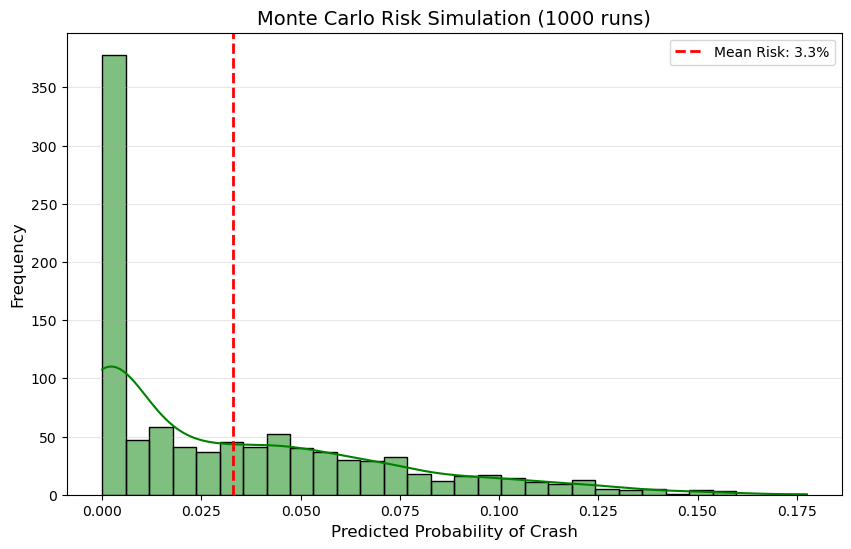

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

print("🎲 Starting Monte Carlo Simulation...")

# --- CONFIGURATION ---
NUM_SIMULATIONS = 1000
# We simulate a "Borderline" build to see how stable the model is
# Scenario: Medium Churn, No Critical Bugs, but Tests are just "Okay"
simulated_churn = 'Medium'
simulated_security = 'Safe'
simulated_test = 'Good'

risk_distribution = []

for i in range(NUM_SIMULATIONS):
    # We add "Noise" to the model's confidence
    # (Simulating that our input data might be slightly wrong)
    
    # 1. Get the base prediction
    base_prob = predict_risk(simulated_churn, simulated_security, simulated_test)
    
    # 2. Add uncertainty (Standard Deviation of 5%)
    # In real life, sensor data or logs have noise.
    noisy_prob = np.random.normal(base_prob, 0.05) 
    
    # Clip result to stay between 0% and 100%
    noisy_prob = max(0.0, min(1.0, noisy_prob))
    
    risk_distribution.append(noisy_prob)

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
sns.histplot(risk_distribution, kde=True, color='green', bins=30)
plt.axvline(np.mean(risk_distribution), color='red', linestyle='dashed', linewidth=2, label=f'Mean Risk: {np.mean(risk_distribution):.1%}')

plt.title(f'Monte Carlo Risk Simulation ({NUM_SIMULATIONS} runs)', fontsize=14)
plt.xlabel('Predicted Probability of Crash', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

print("✅ Simulation Complete. Displaying Graph...")
plt.show()

In [15]:
!pip install graphviz

In [17]:
import os
import subprocess

# Potential locations for the 'dot' executable on your system
paths = [
    r'C:\Users\chera\anaconda3\Library\bin',
    r'C:\Users\chera\anaconda3\Library\bin\graphviz',
    r'C:\Program Files\Graphviz\bin'
]

for p in paths:
    if os.path.isdir(p):
        os.environ["PATH"] += os.pathsep + p

# Test if 'dot' is now visible
try:
    subprocess.run(['dot', '-V'], check=True)
    print("Graphviz engine found successfully!")
except:
    print("Graphviz engine still not in PATH.")

Graphviz engine found successfully!


C:\Users\chera\anaconda3\lib\site-packages\xgboost\plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


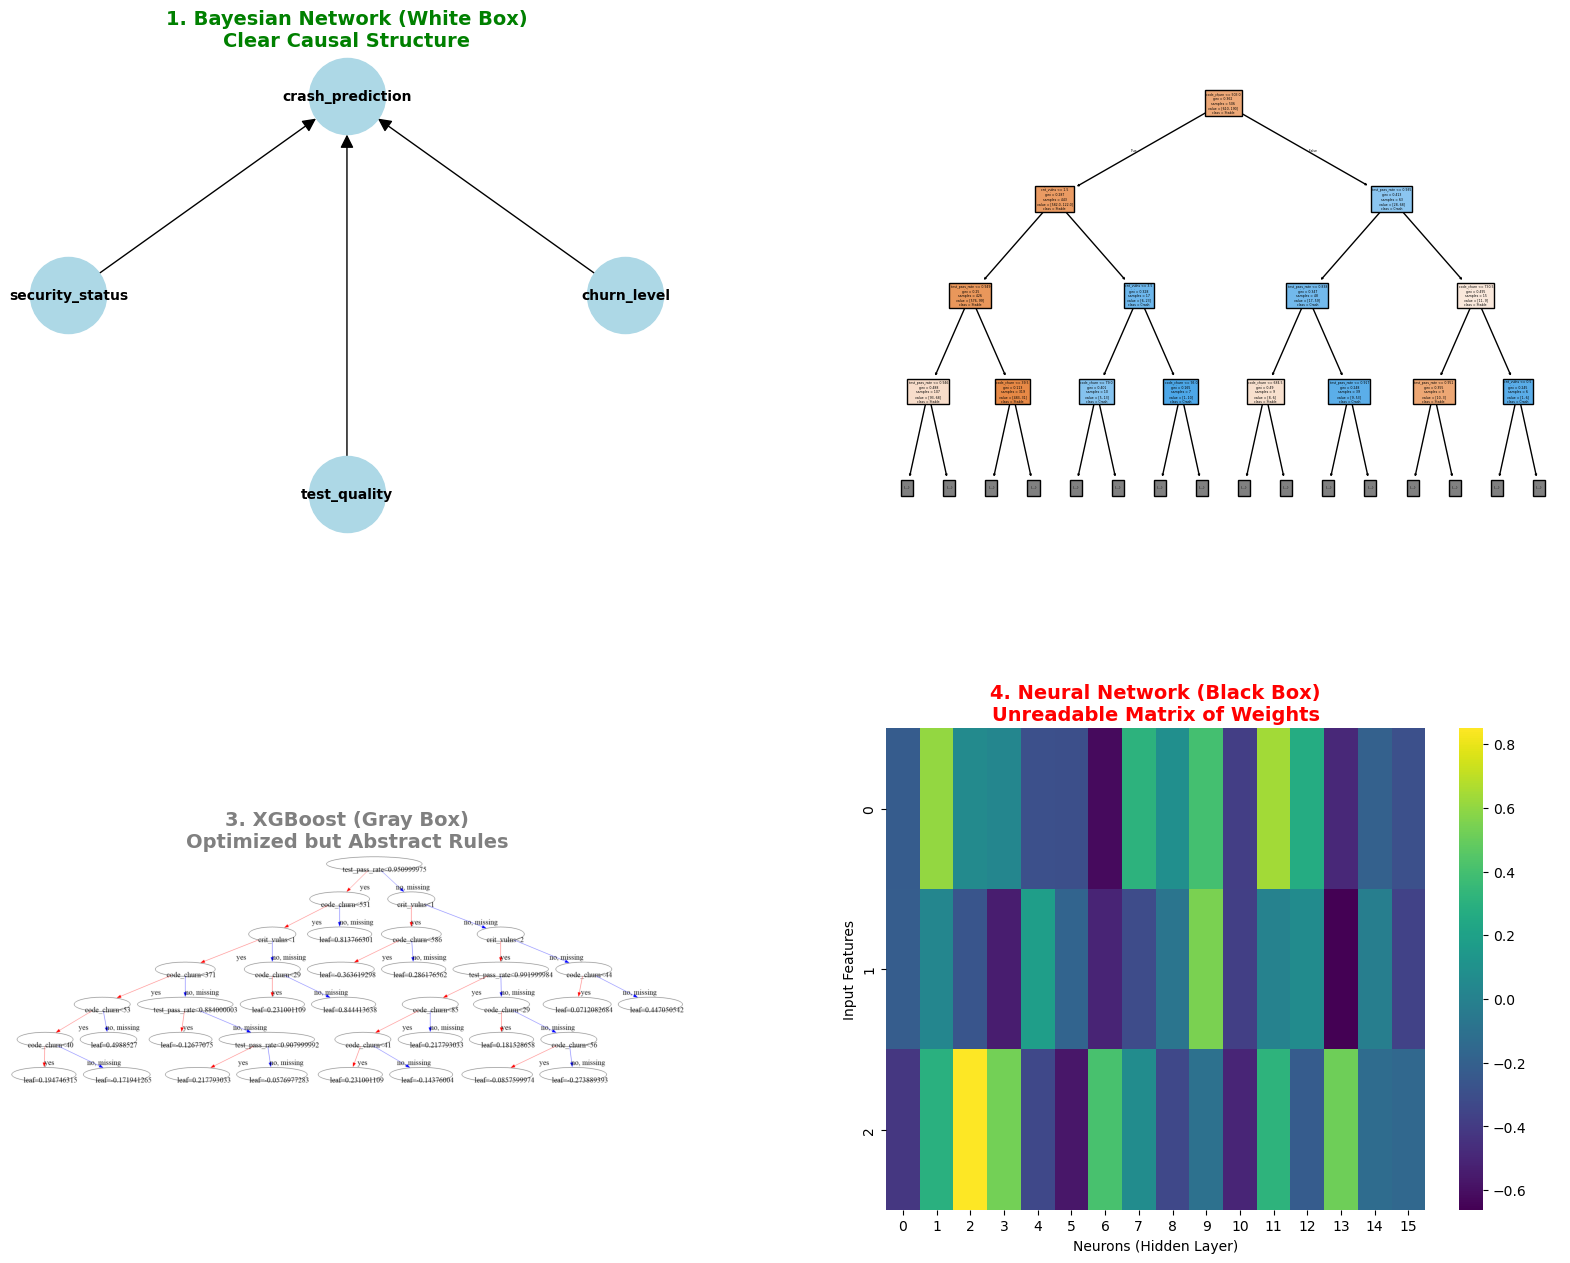

In [19]:
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.tree import plot_tree
import xgboost as xgb
import seaborn as sns

# Create a canvas for 4 plots
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- 1. WHITE BOX: Bayesian Network ---
axes[0, 0].set_title("1. Bayesian Network (White Box)\nClear Causal Structure", fontsize=14, fontweight='bold', color='green')

# FIX: We calculate the layout explicitly ('circular' ensures no overlap)
pos = nx.circular_layout(model) 
nx.draw(model, pos=pos, with_labels=True, ax=axes[0, 0], 
        node_size=3000, node_color="lightblue", 
        font_size=10, font_weight="bold", arrowsize=20)

# --- 2. GRAY BOX: Random Forest ---
axes[0, 1].set_title("2. Random Forest (Gray Box)\nComplex Flowchart of Rules", fontsize=14, fontweight='bold', color='gray')
# Plotting just the first tree
plot_tree(rf_model.estimators_[0], feature_names=X.columns, 
          class_names=['Stable', 'Crash'], filled=True, ax=axes[0, 1], max_depth=3)

# --- 3. GRAY BOX: XGBoost ---
axes[1, 0].set_title("3. XGBoost (Gray Box)\nOptimized but Abstract Rules", fontsize=14, fontweight='bold', color='gray')
xgb.plot_tree(xgb_model, num_trees=0, ax=axes[1, 0])

# --- 4. BLACK BOX: Neural Network ---
axes[1, 1].set_title("4. Neural Network (Black Box)\nUnreadable Matrix of Weights", fontsize=14, fontweight='bold', color='red')
sns.heatmap(nn_model.coefs_[0], ax=axes[1, 1], cmap="viridis", cbar=True)
axes[1, 1].set_xlabel("Neurons (Hidden Layer)")
axes[1, 1].set_ylabel("Input Features")

plt.show()

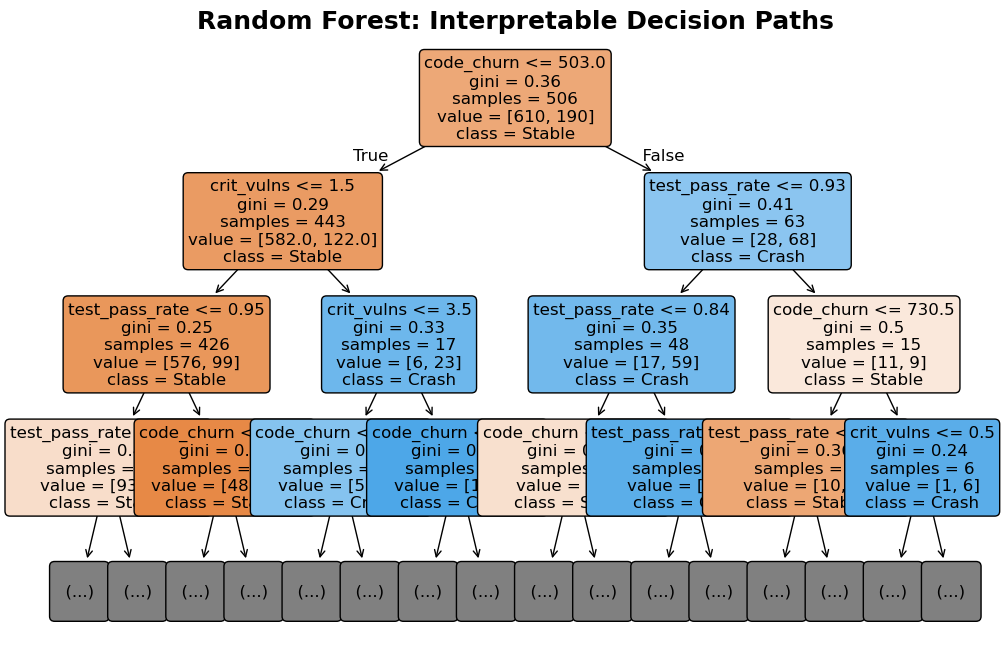

In [21]:
# Figure 2: Random Forest Tree
plt.figure(figsize=(12, 8))
plot_tree(rf_model.estimators_[0], 
          feature_names=X.columns, 
          class_names=['Stable', 'Crash'], 
          filled=True, rounded=True, precision=2,
          fontsize=12, max_depth=3) # Increased font size
plt.title("Random Forest: Interpretable Decision Paths", fontsize=18, fontweight='bold')
plt.savefig('2_Random_Forest.png', dpi=300)
plt.show()

StopIteration: 

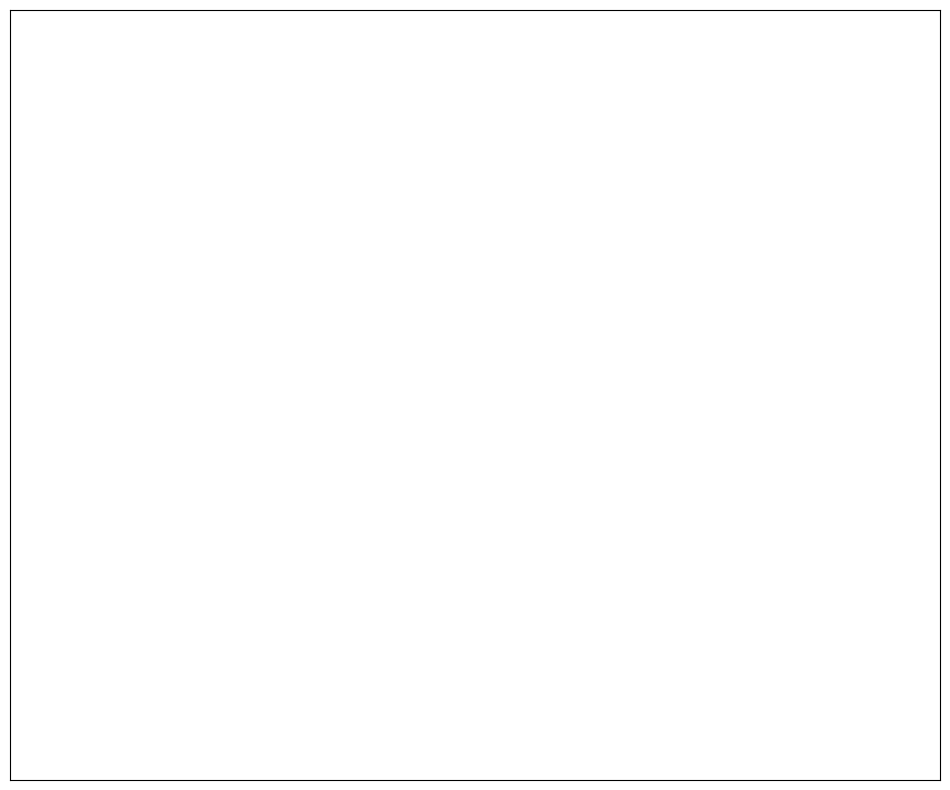

In [33]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Clear any failed plot state to reset the path iterator
plt.clf()
plt.close('all')

# 2. Setup the figure
fig, ax = plt.subplots(figsize=(12, 10))

# 3. Create a stable layout
pos = nx.spring_layout(model, k=1.5, seed=42)

# 4. Draw with the 'Safe' connection style
nx.draw(model, pos=pos, 
        with_labels=True, 
        node_size=5000, 
        node_color="#98FB98", 
        font_size=14, 
        font_weight="bold", 
        arrowsize=30, 
        edge_color="gray", 
        width=2,
        # CRITICAL: 'rad=0' ensures straight lines, bypassing the bezier.py crash
        connectionstyle='arc3,rad=0', 
        ax=ax)

plt.title("Bayesian Network: Causal Structure", fontsize=18, fontweight='bold', pad=20)

# 5. Save for your PPT
plt.tight_layout()
plt.savefig('1_Bayesian_Network_Fixed.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\chera\anaconda3\lib\site-packages\xgboost\plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


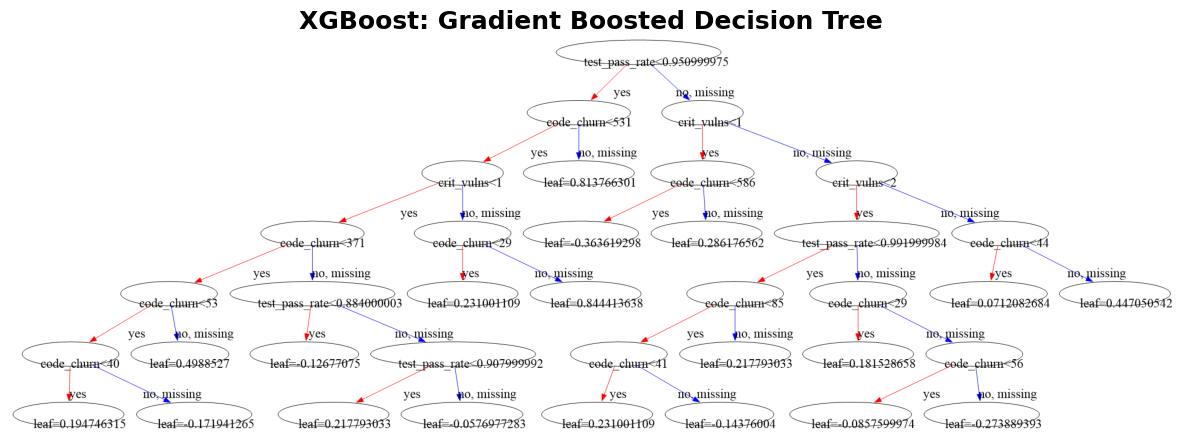

In [25]:
# Figure 3: XGBoost Tree
fig, ax = plt.subplots(figsize=(15, 10))
xgb.plot_tree(xgb_model, num_trees=0, ax=ax)
# Adjusting text properties after plotting
for text in ax.texts:
    text.set_fontsize(13)
    text.set_fontweight('bold')
plt.title("XGBoost: Gradient Boosted Decision Tree", fontsize=18, fontweight='bold')
plt.savefig('3_XGBoost_Tree.png', dpi=300)
plt.show()

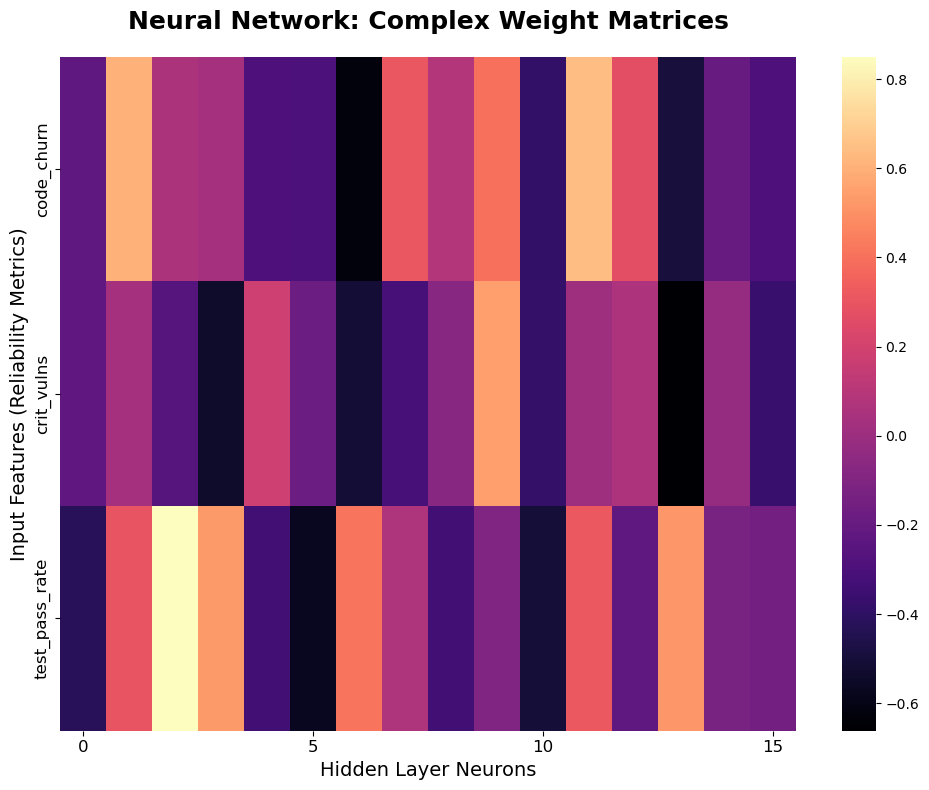

In [27]:
# Figure 4: Neural Network Weights
plt.figure(figsize=(10, 8))
ax = sns.heatmap(nn_model.coefs_[0], cmap="magma", cbar=True,
                 xticklabels=5, yticklabels=X.columns) # Label Y-axis with features
plt.title("Neural Network: Complex Weight Matrices", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Hidden Layer Neurons", fontsize=14)
plt.ylabel("Input Features (Reliability Metrics)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('4_Neural_Network.png', dpi=300)
plt.show()